# Braunschweig  — Validation against MiD 2023

This notebook compares the eqasim 1%-sample synthetic population for the
Großraum Braunschweig (ZGB-8 Kreise) against the **MiD 2023** regional
reference tables (infas sample 7555):

| Table  | Indicator                       |
|--------|---------------------------------|
| P9     | employment status (Erwerbstätigkeit) |
| P12_1  | modal split (Hauptverkehrsmittel Arbeitsweg) |
| P13    | commute distance distribution (Arbeitsweg-Länge) |
| P17_1  | driver license rate (Führerschein-Quote) |

Synthetic inputs come from `eqasim-data/output_bs/braunschweig_25pct_*`
produced by the synpp pipeline.  The MiD CSVs live in
`eqasim-data/data/braunschweig/mid/`.

All numeric reference values are % shares per Kreis.  The ZGB-8 covers
AGS-5 prefixes `03101, 03102, 03103, 03151, 03153, 03154, 03157, 03158`.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

REPO = Path.cwd()
while REPO.name and not (REPO / "config_local_braunschweig.yml").exists():
    REPO = REPO.parent
assert (REPO / "config_local_braunschweig.yml").exists(), REPO

OUTPUT = REPO / "eqasim-data" / "output_bs_25pct"
MID    = REPO / "eqasim-data" / "data" / "braunschweig" / "mid"
PREFIX = "braunschweig_25pct_"

ZGB8 = {
    "03101": "SK Braunschweig",
    "03102": "SK Salzgitter",
    "03103": "SK Wolfsburg",
    "03151": "LK Gifhorn",
    "03153": "LK Goslar",
    "03154": "LK Helmstedt",
    "03157": "LK Peine",
    "03158": "LK Wolfenbüttel",
}

plt.rcParams.update({"figure.figsize": (9, 4.5), "figure.dpi": 110})
print("Repo:", REPO)
print("Output:", OUTPUT)
print("MiD   :", MID)


Repo: C:\Users\bienzeisler\Documents\GitHub\eqasim-bs
Output: C:\Users\bienzeisler\Documents\GitHub\eqasim-bs\eqasim-data\output_bs_25pct
MiD   : C:\Users\bienzeisler\Documents\GitHub\eqasim-bs\eqasim-data\data\braunschweig\mid


## 1. Load synthetic output + MiD reference tables


In [2]:
def _read_csv(name: str) -> pd.DataFrame:
    return pd.read_csv(OUTPUT / f"{PREFIX}{name}.csv", sep=";")

persons    = _read_csv("persons")
households = _read_csv("households")
trips      = _read_csv("trips")

homes       = gpd.read_file(OUTPUT / f"{PREFIX}homes.gpkg")
activities  = gpd.read_file(OUTPUT / f"{PREFIX}activities.gpkg")
trips_geo   = gpd.read_file(OUTPUT / f"{PREFIX}trips.gpkg")
commutes    = gpd.read_file(OUTPUT / f"{PREFIX}commutes.gpkg")

# MiD reference tables
mid = {}
for code in ("P9", "P12_1", "P13", "P17_1"):
    df = pd.read_csv(MID / f"mid2023_{code}.csv")
    df["ars5"]  = df["ars5"].astype(str)
    df["kreis"] = df["kreis"].astype(str)
    mid[code] = df

print("persons   :", len(persons))
print("households:", len(households))
print("trips     :", len(trips))
print("homes     :", len(homes),     homes.crs)
print("activities:", len(activities), activities.crs)
print("commutes  :", len(commutes))
print("MiD tables:", {k: len(v) for k, v in mid.items()})


persons   : 284801
households: 141321
trips     : 886782
homes     : 141153 EPSG:25832
activities: 1171583 EPSG:25832
commutes  : 78385
MiD tables: {'P9': 9, 'P12_1': 9, 'P13': 9, 'P17_1': 9}


## 2. Attach home Kreis (AGS-5) to every person

The activities GPKG carries `household_id` + the home geometry — we join
against `data/spatial/communes.gpkg` (VG250) to obtain AGS-8 and truncate
to AGS-5 for the Kreis match with MiD.


In [3]:
import zipfile

VG250_ZIP = REPO / "eqasim-data" / "data" / "germany" / \
    "vg250-ew_12-31.utm32s.gpkg.ebenen.zip"
VG250_INNER = ("vg250-ew_12-31.utm32s.gpkg.ebenen/"
               "vg250-ew_ebenen_1231/DE_VG250.gpkg")

with zipfile.ZipFile(VG250_ZIP) as z, z.open(VG250_INNER) as f:
    vg = gpd.read_file(f, layer="vg250_gem")

# Keep only Niedersachsen ZGB-8 Kreise, dissolve to one polygon per Kreis.
vg["ars5"] = vg["ARS"].astype(str).str[:5]
kreise = (vg[vg["ars5"].isin(ZGB8)][["ars5", "geometry"]]
          .dissolve(by="ars5", as_index=False)
          .to_crs(homes.crs))
kreise["kreis_name"] = kreise["ars5"].map(ZGB8)

# Spatial-join home locations → Kreis.
homes_kreis = gpd.sjoin(
    homes, kreise[["ars5", "kreis_name", "geometry"]],
    how="left", predicate="within",
).drop(columns="index_right")

persons_kreis = persons.merge(
    homes_kreis[["household_id", "ars5", "kreis_name"]],
    on="household_id", how="left",
)
print("Unassigned homes:",
      persons_kreis["ars5"].isna().sum(), "/", len(persons_kreis))
print(persons_kreis.groupby("kreis_name", dropna=False)
      .size().rename("synthetic_persons"))


C:\Users\bienzeisler\AppData\Local\miniforge3\envs\eqasim\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: File /vsimem/pyogrio_b0ddc50f20f24fccb7155a19759b5e0c has GPKG application_id, but non conformant file extension
  return ogr_read(


Unassigned homes: 168 / 284801
kreis_name
LK Gifhorn         43920
LK Goslar          31612
LK Helmstedt       22744
LK Peine           34129
LK Wolfenbüttel    29677
SK Braunschweig    63085
SK Salzgitter      26192
SK Wolfsburg       33274
NaN                  168
Name: synthetic_persons, dtype: int64


## 3. Demographics — age / sex / employment / household size / car ownership

Basic sanity check of the enriched population.  No MiD comparison here —
only the synthetic distributions.


Persons   : 284801
Age       : mean=45.2  median=46  min=0  max=99
Sex       : {'female': 0.504, 'male': 0.496}
Employed  : {False: 0.589, True: 0.411}
License   : {True: 0.588, False: 0.412}

Household size mean (5+ counted as 5): 2.02
Household size shares:
1     43.0
2     31.5
3     12.3
4      8.7
5+     0.0
Cars mean          : 1.20
Bicycles mean      : 1.82


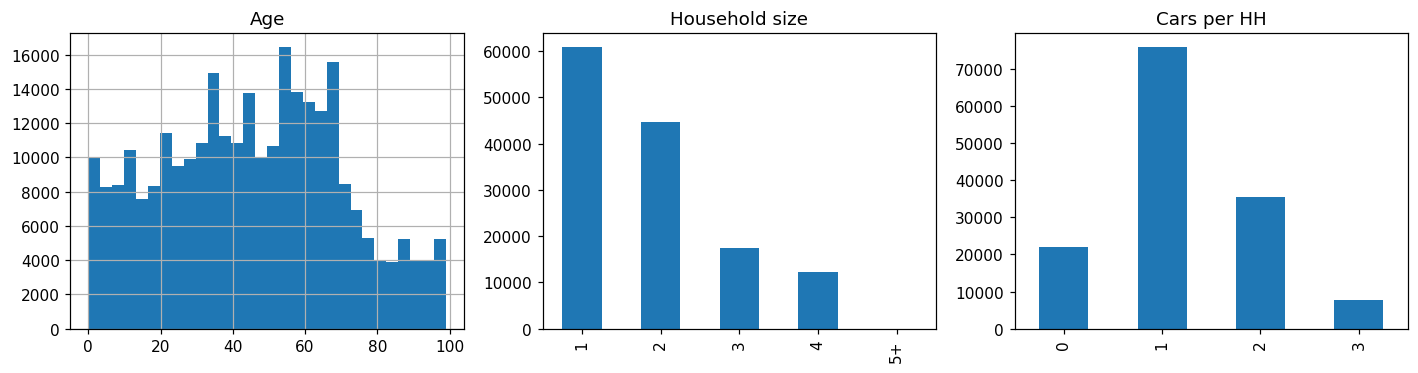

In [4]:
for col in ("number_of_cars", "number_of_bicycles"):
    households[col] = pd.to_numeric(households[col], errors="coerce")

# household_size arrives as the Bavaria delegate's categorical labels
# ("1","2","3","4","5+"). Map the top-coded "5+" to 5 so the mean/plots
# use the nominal floor rather than dropping the largest households.
HHSIZE_ORDER = ["1", "2", "3", "4", "5+"]
households["household_size"] = households["household_size"].astype(str)
households["household_size_num"] = (households["household_size"]
    .replace({"5+": "5"}).pipe(pd.to_numeric, errors="coerce"))

print("Persons   :", len(persons_kreis))
print("Age       : mean={:.1f}  median={}  min={}  max={}".format(
    persons_kreis["age"].mean(), int(persons_kreis["age"].median()),
    persons_kreis["age"].min(), persons_kreis["age"].max()))
print("Sex       :", persons_kreis["sex"].value_counts(normalize=True).round(3).to_dict())
print("Employed  :", persons_kreis["employed"].value_counts(normalize=True).round(3).to_dict())
print("License   :", persons_kreis["has_driving_license"].value_counts(normalize=True).round(3).to_dict())
print()
print("Household size mean (5+ counted as 5): {:.2f}".format(
    households["household_size_num"].mean()))
print("Household size shares:")
print((households["household_size"].value_counts(normalize=True)
       .reindex(HHSIZE_ORDER).fillna(0).round(3) * 100).to_string())
print("Cars mean          : {:.2f}".format(households["number_of_cars"].mean()))
print("Bicycles mean      : {:.2f}".format(households["number_of_bicycles"].mean()))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
persons_kreis["age"].hist(bins=30, ax=axes[0]); axes[0].set_title("Age")
(households["household_size"].value_counts()
    .reindex(HHSIZE_ORDER).fillna(0)
    .plot.bar(ax=axes[1]))
axes[1].set_title("Household size")
households["number_of_cars"].value_counts().sort_index().plot.bar(ax=axes[2]); axes[2].set_title("Cars per HH")
plt.tight_layout(); plt.show()


## 4. Activity chains


home         649813
leisure      137563
work         127570
shop         109308
other         93919
education     53410
Name: purpose, dtype: int64
Avg activities/person : 4.11


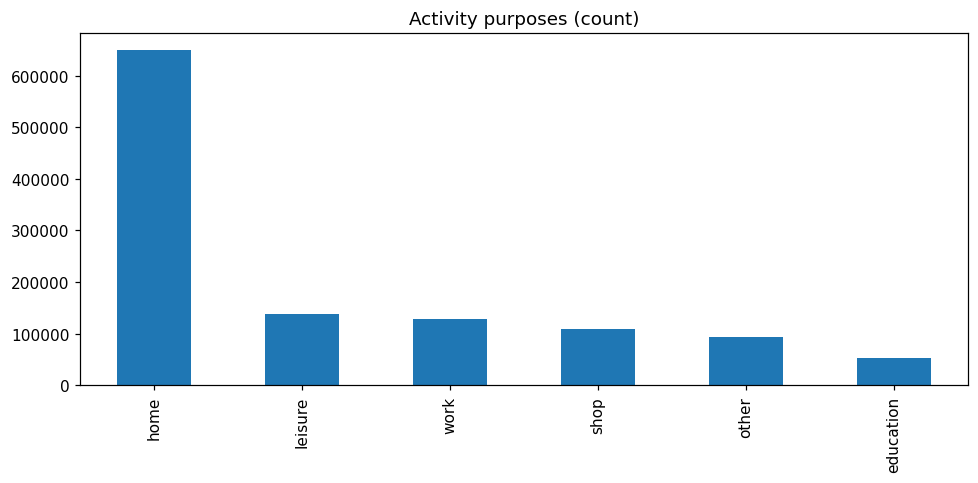

In [5]:
purpose_counts = activities["purpose"].value_counts()
print(purpose_counts)
print("Avg activities/person : {:.2f}".format(
    len(activities) / persons_kreis["person_id"].nunique()))

purpose_counts.plot.bar(title="Activity purposes (count)"); plt.tight_layout(); plt.show()


## 5. Trip characteristics — duration, departure time, OD purpose pairs


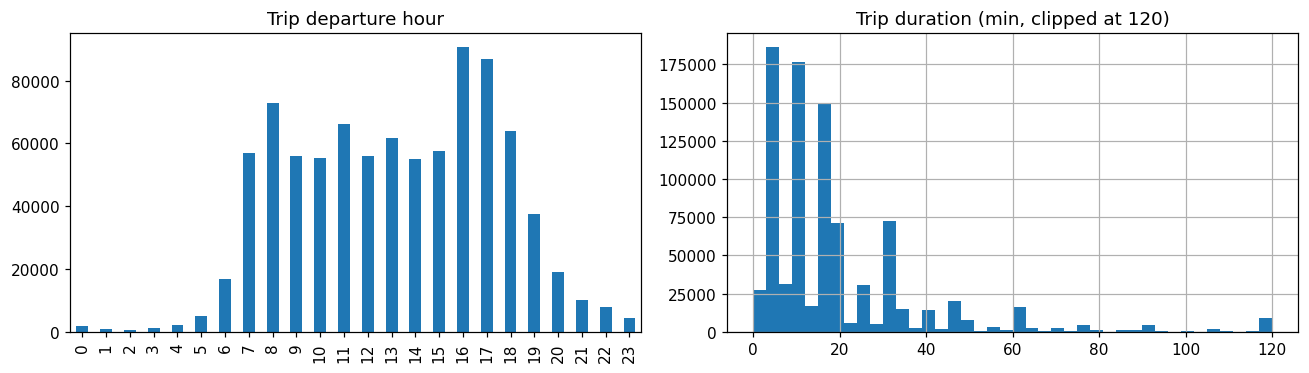

Top OD purpose pairs:
preceding_purpose  following_purpose
leisure            home                 95143
home               leisure              90147
shop               home                 85567
home               work                 85361
work               home                 80450
home               shop                 75933
                   other                67345
other              home                 62283
home               education            47834
education          home                 44997
dtype: int64


In [6]:
trips = trips.copy()
trips["duration_min"] = (trips["arrival_time"] - trips["departure_time"]) / 60.0
trips["departure_hour"] = (trips["departure_time"] // 3600).astype(int) % 24

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
trips["departure_hour"].value_counts().sort_index().plot.bar(
    ax=axes[0], title="Trip departure hour")
trips["duration_min"].clip(upper=120).hist(bins=40, ax=axes[1])
axes[1].set_title("Trip duration (min, clipped at 120)")
plt.tight_layout(); plt.show()

pair = (trips.groupby(["preceding_purpose", "following_purpose"])
        .size().unstack(fill_value=0))
print("Top OD purpose pairs:")
print(pair.stack().sort_values(ascending=False).head(10))


## 6. Spatial distribution — homes + secondary activities


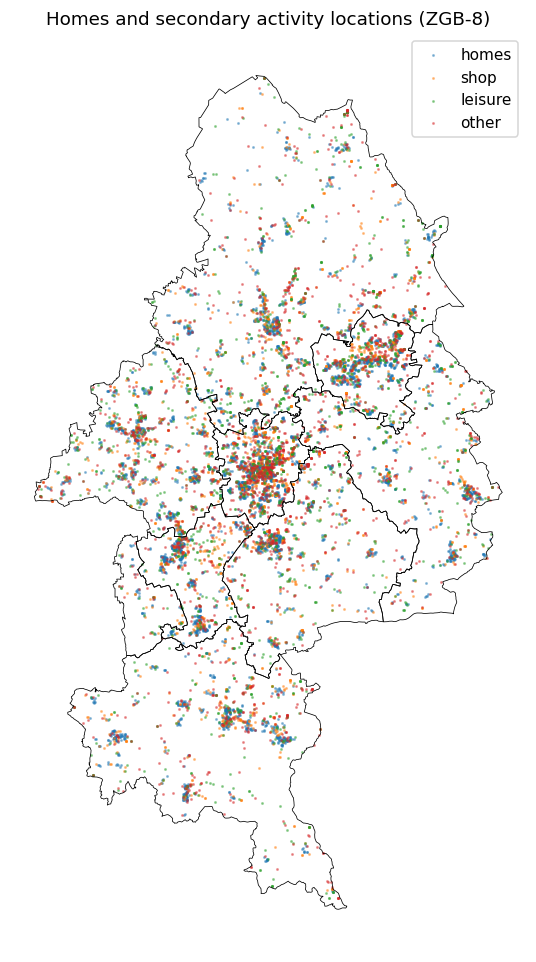

In [7]:
fig, ax = plt.subplots(figsize=(10, 9))
kreise.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Subsample for speed
homes.sample(min(len(homes), 5000), random_state=0).plot(
    ax=ax, markersize=1, color="tab:blue", label="homes", alpha=0.4)

for purpose, color in [("shop", "tab:orange"), ("leisure", "tab:green"),
                        ("other", "tab:red")]:
    sub = activities[activities["purpose"] == purpose]
    sub.sample(min(len(sub), 2000), random_state=0).plot(
        ax=ax, markersize=1, color=color, label=purpose, alpha=0.4)

ax.set_title("Homes and secondary activity locations (ZGB-8)")
ax.legend()
ax.set_axis_off()
plt.tight_layout(); plt.show()


## 7. Commute distance per Kreis — synthetic vs MiD P13

Compute Euclidean home→work distances using the activities GPKG. One
distance per working person (first ``work`` activity).


In [8]:
work_act = activities[activities["purpose"] == "work"].drop_duplicates("person_id")[
    ["person_id", "household_id", "geometry"]
].rename(columns={"geometry": "work_geom"})

home_lookup = homes_kreis[["household_id", "geometry"]].rename(
    columns={"geometry": "home_geom"}
).drop_duplicates("household_id")

commute = work_act.merge(home_lookup, on="household_id", how="inner")
commute["distance_km"] = commute.apply(
    lambda r: r["home_geom"].distance(r["work_geom"]) / 1000.0, axis=1
)
commute = commute.merge(
    persons_kreis[["person_id", "ars5", "kreis_name"]],
    on="person_id", how="left",
)
print("Commute pairs:", len(commute))
print(commute[["distance_km"]].describe())

BANDS = [(0, 0.5, "d_0"), (0.5, 5, "d_0_5"), (5, 10, "d_5_10"),
         (10, 20, "d_10_20"), (20, 30, "d_20_30"), (30, 50, "d_30_50"),
         (50, 100, "d_50_100"), (100, np.inf, "d_100p")]

def band_share(distances_km: np.ndarray) -> dict:
    return {name: 100.0 * np.mean((distances_km >= lo) & (distances_km < hi))
            for lo, hi, name in BANDS}

p13 = mid["P13"].set_index("ars5")
rows = []
for ars5, label in ZGB8.items():
    sub = commute[commute["ars5"] == ars5]
    if sub.empty:
        continue
    syn = band_share(sub["distance_km"].values)
    ref = p13.loc[ars5]
    for lo, hi, name in BANDS:
        rows.append({"ars5": ars5, "kreis": label, "band": name,
                     "synthetic_pct": syn[name],
                     "mid_pct": float(ref.get(name, np.nan))})

compare = pd.DataFrame(rows)
compare

Commute pairs: 78617
        distance_km
count  78617.000000
mean      25.685097
std       55.584175
min        0.012016
25%        4.539592
50%        9.816170
75%       24.396205
max      527.190481


,ars5,kreis,band,synthetic_pct,mid_pct
0,03101,SK Braunschweig,d_0,1.769464,2.0
1,03101,SK Braunschweig,d_0_5,31.799798,23.0
2,03101,SK Braunschweig,d_5_10,30.592068,22.0
3,03101,SK Braunschweig,d_10_20,10.599933,13.0
4,03101,SK Braunschweig,d_20_30,11.588586,9.0
...,...,...,...,...,...
59,03158,LK Wolfenbüttel,d_10_20,28.918025,28.0
60,03158,LK Wolfenbüttel,d_20_30,15.782380,16.0
61,03158,LK Wolfenbüttel,d_30_50,8.920475,10.0
62,03158,LK Wolfenbüttel,d_50_100,4.423478,5.0


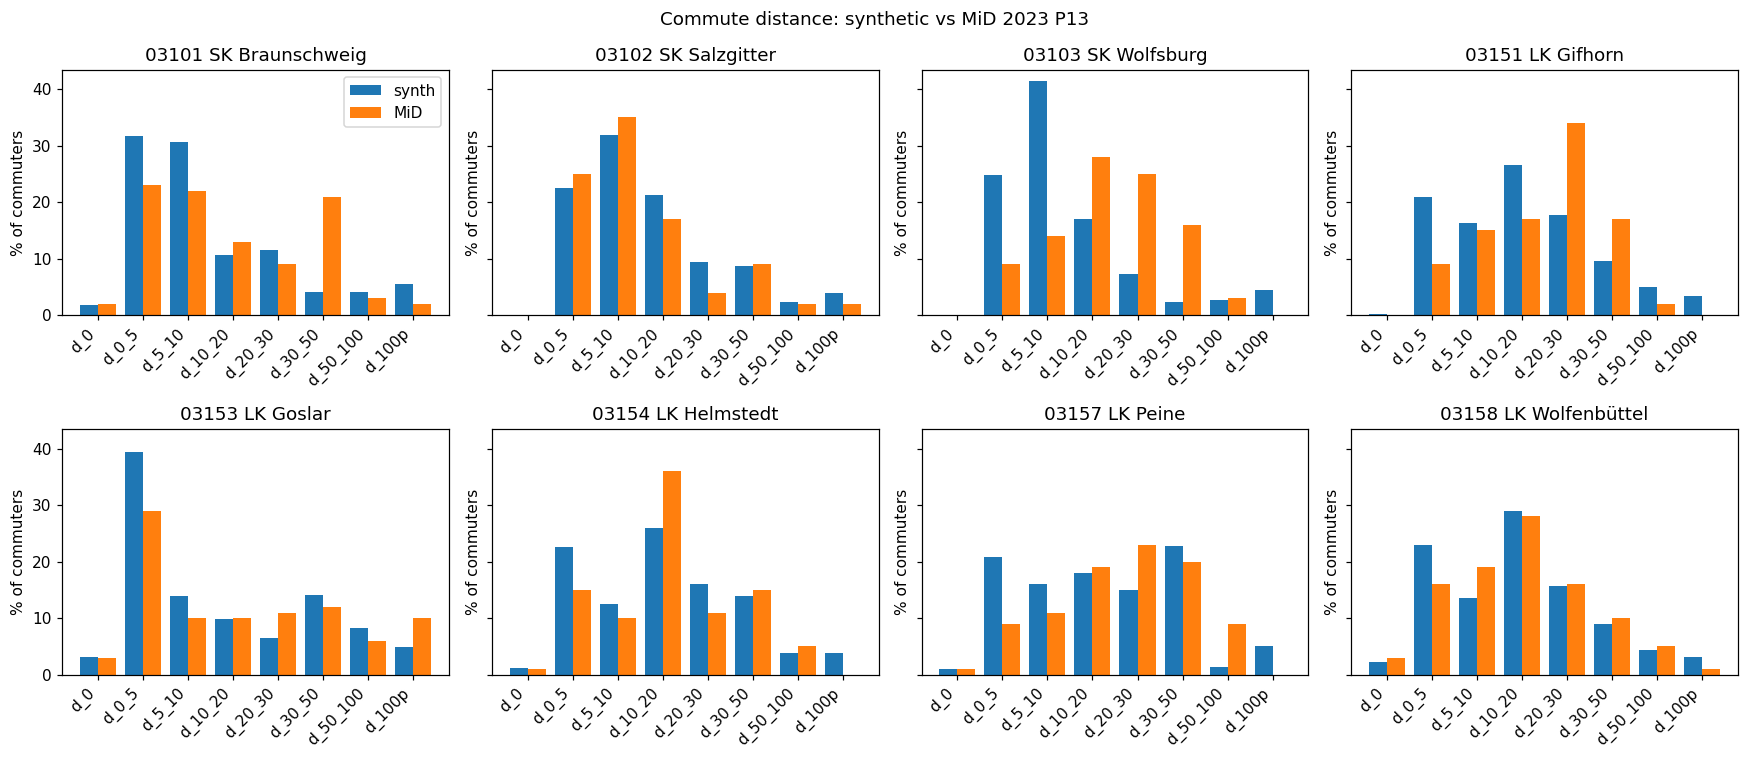

,kreis,mean_synthetic_km,mean_mid_km,delta_km
ars5,,,,
03101,SK Braunschweig,25.4,19.1,6.3
03102,SK Salzgitter,22.8,13.7,9.1
03103,SK Wolfsburg,22.7,18.4,4.3
03151,LK Gifhorn,25.9,20.8,5.1
03153,LK Goslar,27.4,29.4,-2.0
03154,LK Helmstedt,27.1,18.5,8.6
03157,LK Peine,30.1,22.6,7.5
03158,LK Wolfenbüttel,24.1,18.0,6.1


In [9]:
kreise_list = list(ZGB8.keys())
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
band_labels = [name for _, _, name in BANDS]
band_x = np.arange(len(band_labels))

for ax, ars5 in zip(axes.ravel(), kreise_list):
    sub = compare[compare["ars5"] == ars5]
    if sub.empty:
        ax.set_axis_off(); continue
    ax.bar(band_x - 0.2, sub["synthetic_pct"], width=0.4, label="synth", color="tab:blue")
    ax.bar(band_x + 0.2, sub["mid_pct"],        width=0.4, label="MiD",   color="tab:orange")
    ax.set_xticks(band_x); ax.set_xticklabels(band_labels, rotation=45, ha="right")
    ax.set_title(f"{ars5} {ZGB8[ars5]}")
    ax.set_ylabel("% of commuters")
axes[0, 0].legend()
plt.suptitle("Commute distance: synthetic vs MiD 2023 P13")
plt.tight_layout(); plt.show()

# Mean commute km
mean_syn = commute.groupby("ars5")["distance_km"].mean()
mean_mid = p13["mittel"]
summary = pd.DataFrame({
    "kreis": mean_syn.index.map(ZGB8),
    "mean_synthetic_km": mean_syn.round(1),
    "mean_mid_km":       mean_mid.reindex(mean_syn.index).round(1),
})
summary["delta_km"] = (summary["mean_synthetic_km"] -
                        summary["mean_mid_km"]).round(1)
summary


## 8. License rate per Kreis — synthetic (KBA FE4) vs MiD P17.1

The pipeline takes driver licenses from the authoritative KBA FE4.4
registry — MiD P17.1 is only a **cross-check** of self-reported rates.
Differences are expected because KBA counts *registered* licenses while
MiD counts *self-reported* possession.


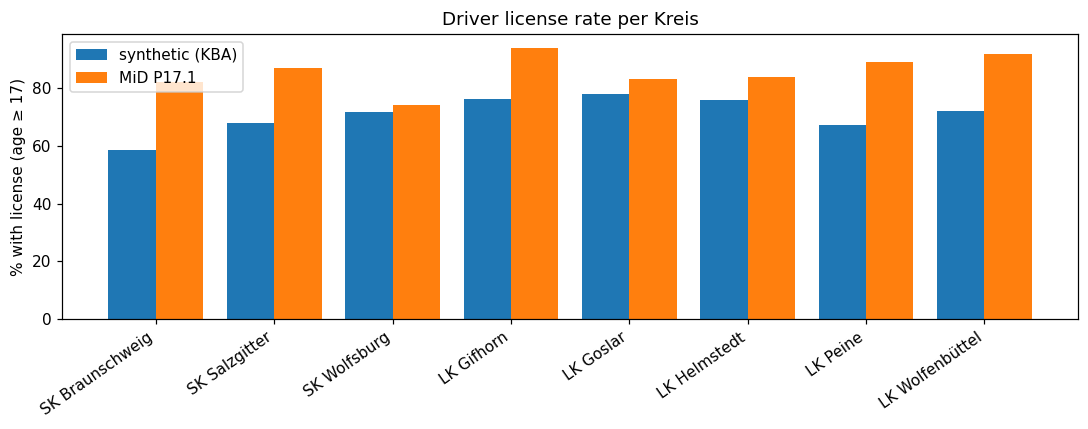

,kreis,synthetic_pct,mid_pct,delta_pp
ars5,,,,
03101,SK Braunschweig,58.6,82.0,-23.4
03102,SK Salzgitter,68.0,87.0,-19.0
03103,SK Wolfsburg,71.8,74.0,-2.2
03151,LK Gifhorn,76.4,94.0,-17.6
03153,LK Goslar,78.0,83.0,-5.0
03154,LK Helmstedt,75.9,84.0,-8.1
03157,LK Peine,67.2,89.0,-21.8
03158,LK Wolfenbüttel,72.1,92.0,-19.9


In [10]:
# Synthetic: restrict to licensable population (age >= 17)
lic_pop = persons_kreis[persons_kreis["age"] >= 17]
lic_syn = (lic_pop.groupby("ars5")["has_driving_license"]
           .apply(lambda s: 100.0 * (s.astype(str).str.lower()
                                     .isin(["true", "1", "yes"])).mean())
           .rename("synthetic_pct"))
lic_mid = mid["P17_1"].set_index("ars5")["ja"]

lic_tbl = pd.DataFrame({
    "kreis":          lic_syn.index.map(ZGB8),
    "synthetic_pct":  lic_syn.round(1),
    "mid_pct":        lic_mid.reindex(lic_syn.index).round(1),
})
lic_tbl["delta_pp"] = (lic_tbl["synthetic_pct"] - lic_tbl["mid_pct"]).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(lic_tbl))
ax.bar(x - 0.2, lic_tbl["synthetic_pct"], width=0.4, label="synthetic (KBA)")
ax.bar(x + 0.2, lic_tbl["mid_pct"],       width=0.4, label="MiD P17.1")
ax.set_xticks(x); ax.set_xticklabels(lic_tbl["kreis"], rotation=35, ha="right")
ax.set_ylabel("% with license (age ≥ 17)")
ax.set_title("Driver license rate per Kreis")
ax.legend()
plt.tight_layout(); plt.show()
lic_tbl


## 9. Employment status (MiD P9) — ZGB aggregate

The synthetic population encodes employment as boolean `employed` (derived
from GENESIS 13111-06-02-4).  MiD P9 breaks down into Vollzeit / Teilzeit
/ Geringfügig / sonstiges / in Ausbildung / nicht erwerbstätig.  We collapse
to a single ``employed_pct`` for comparison.


In [11]:
work_pop = persons_kreis[persons_kreis["age"].between(15, 74)]
emp_syn = (work_pop.groupby("ars5")["employed"]
           .apply(lambda s: 100.0 * (s.astype(str).str.lower()
                                     .isin(["true", "1", "yes"])).mean())
           .rename("synthetic_pct"))

p9 = mid["P9"].set_index("ars5")
emp_mid = (p9["vollzeit"].fillna(0) + p9["teilzeit"].fillna(0) +
           p9["geringfuegig"].fillna(0) + p9["sonstiges"].fillna(0) +
           p9["erwerbstaetig_unspec"].fillna(0))

emp_tbl = pd.DataFrame({
    "kreis":         emp_syn.index.map(ZGB8),
    "synthetic_pct": emp_syn.round(1),
    "mid_pct":       emp_mid.reindex(emp_syn.index).round(1),
})
emp_tbl["delta_pp"] = (emp_tbl["synthetic_pct"] - emp_tbl["mid_pct"]).round(1)
emp_tbl


,kreis,synthetic_pct,mid_pct,delta_pp
ars5,,,,
03101,SK Braunschweig,54.6,51.0,3.6
03102,SK Salzgitter,51.7,52.0,-0.3
03103,SK Wolfsburg,55.4,43.0,12.4
03151,LK Gifhorn,56.0,59.0,-3.0
03153,LK Goslar,51.9,48.0,3.9
03154,LK Helmstedt,56.4,48.0,8.4
03157,LK Peine,56.0,50.0,6.0
03158,LK Wolfenbüttel,54.9,58.0,-3.1


## 10. Secondary-location assignment success

The pipeline reports a single ``Success rate`` at the end of secondary
location sampling (~0.749 in the current dry run).  Here we break it
down: how many activities ended up with a valid geometry vs fallback
coordinates, and per purpose.


In [12]:
valid = activities["geometry"].notna() & ~activities["geometry"].is_empty
by_purpose = pd.DataFrame({
    "total":     activities.groupby("purpose").size(),
    "valid_geom": activities[valid].groupby("purpose").size(),
}).fillna(0).astype(int)
by_purpose["success_pct"] = (100.0 * by_purpose["valid_geom"] /
                             by_purpose["total"]).round(2)
print(by_purpose)

# Activities outside the ZGB-8 Kreis polygons (potential leakage)
act_in = gpd.sjoin(activities, kreise[["ars5", "geometry"]],
                   how="left", predicate="within")
leak = (act_in["ars5"].isna().groupby(act_in["purpose"]).mean() * 100).round(2)
print("\nActivities outside ZGB-8 polygon (%):")
print(leak)


            total  valid_geom  success_pct
purpose                                   
education   53410       53410        100.0
home       649813      649813        100.0
leisure    137563      137563        100.0
other       93919       93919        100.0
shop       109308      109308        100.0
work       127570      127570        100.0



Activities outside ZGB-8 polygon (%):
purpose
education     0.00
home          0.00
leisure       0.00
other         0.00
shop          0.00
work         12.55
Name: ars5, dtype: float64
